# Plotting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lldddv2/relatipy/blob/main/docs/tutorials/05-plotting.ipynb)

This tutorial shows:

- how to preview an orbit before integrating it;
- how to plot an integrated `Solution` in its static projections and against time;
- how to draw several solutions in one figure;
- which helpers of `relatipy.plotting` you can use to style figures.

All RelatiPy figure functions
return Matplotlib (or Plotly) objects without showing or saving them; we only lower
the screen resolution to keep this notebook small.

In [ ]:
%pip install -Uq relatipy

In [1]:
import numpy as np
from astropy import units as u

import relatipy as rp

## 1. A strong-field orbit

We use a one-solar-mass black hole with spin $a = 0.7$ and an inclined, eccentric
orbit given by classical osculating elements. The semi-major axis is written in
units of the Schwarzschild radius, $r_s = 2GM/c^2$, through `bh.r_s`, and converted
to kilometres so that lengths are stored and displayed in kilometres. The true anomaly `f`
defaults to zero, so the orbit starts at the osculating periapsis.

In [2]:
bh = rp.Kerr(mass=1 * u.Msun, spin=0.7)
a = (10 * bh.r_s).to(u.km)
orbit = bh.orbit(
    a=a, e=0.4, inc=0.5 * u.rad, Omega=0.3 * u.rad, omega=0.8 * u.rad,
)

print("r_s             =", bh.r_s.to(u.km))
print("outer horizon   =", (bh.horizons.event / bh.r_s).decompose(), "r_s")
print("prograde ISCO   =", (bh.r_isco_prograde / bh.r_s).decompose(), "r_s")
print("retrograde ISCO =", (bh.r_isco_retrograde / bh.r_s).decompose(), "r_s")

r_s             = 2.95325007610025 km
outer horizon   = 0.8570714214271425 r_s
prograde ISCO   = 1.696564235090815 r_s
retrograde ISCO = 4.071482732417158 r_s


## 2. Previewing an orbit with `Orbit.preview`

`Orbit.preview` draws the *instantaneous osculating Kepler conic* of the current
state. It is not an integrated Kerr trajectory and it never advances the orbit, so it
is a cheap check of the initial conditions. By default it also draws two equatorial
reference circles: the outer horizon (`show_horizon=True`) and the prograde and
retrograde ISCO (`show_isco=True`). Their Cartesian radii come from the native Kerr
kernel.

The default projection, `"views"`, is a static Matplotlib figure with three
orthogonal Cartesian planes at one shared physical scale. It returns
`(fig, (main, top, right))`. Lengths are displayed in the stored position unit, here
kilometres.

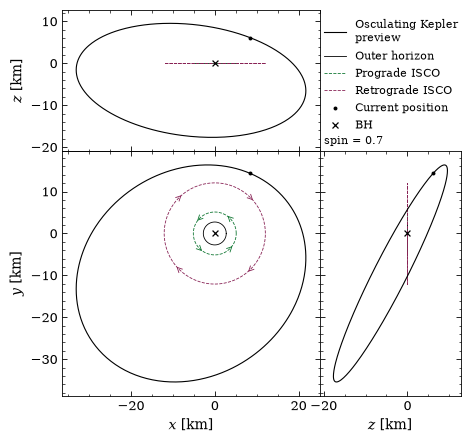

In [3]:
fig, (main, top, right) = orbit.preview()

## 3. Integrating and plotting a `Solution`

`Solution.plot` connects the *stored* samples of a solution; it neither interpolates
nor integrates. To get a smooth curve, request dense output times with `tau_eval`.
As a time unit we use the Keplerian period of the conic, returned by
`orbit.get_keplerian_period()` as $P = 2\pi\,(a^3/GM)^{1/2}$, which for $a = 10\,r_s$ equals $2\pi\,(2000)^{1/2}\,r_s/c$, and integrate
over $2P$ of proper time.

In [4]:
period = orbit.get_keplerian_period().to(u.ms)
taus = np.linspace(0, 2, 600) * period
solution = orbit.solve(tau_eval=taus)

print("P =", period)
print("status:", solution.status)
print("success:", solution.success)
print("samples:", len(solution))
print("R range of the stored samples:", (solution.R.min() / bh.r_s).decompose(), "to",
      (solution.R.max() / bh.r_s).decompose(), "r_s")

P = 2.7680529093278534 ms
status: 0
success: True
samples: 600
R range of the stored samples: 5.99099598608218 to 24.16207320263963 r_s


### 3.1 Static projections

`projection` accepts `"3d"`, `"xy"`, `"xz"`, `"yz"` and `"views"` (the default).
The planes and `"views"` are always static Matplotlib figures. A plane returns a
`(fig, ax)` pair; the spin is written in a corner note. Unlike the preview, a
solution plot has no horizon or ISCO circles. Compare with the preview above: in this strong-field example the integrated Kerr
trajectory reaches larger radii than the initial osculating conic, which is why the
preview is only a check of the initial state. With the A&A target from
`relatipy.plotting.TARGETS`, the same figure is drawn at a one-column width of 88 mm.

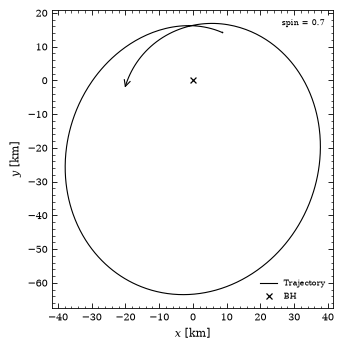

In [5]:
aanda_style = rp.plotting.DEFAULT_STYLE.replace(target="aanda")

fig, ax = solution.plot(projection="xy", style=aanda_style)

### 3.2 Three-dimensional view

An explicit `projection="3d"` returns an interactive Plotly figure by default. Pass
`interactive=False` to obtain a static Matplotlib 3D axes instead, which is what we
use here so the notebook contains only static images. The three spatial axes share
one physical scale.

3d


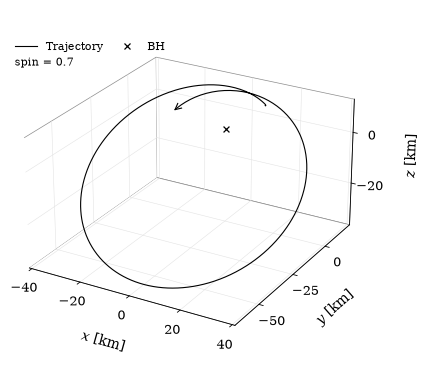

In [6]:
fig, ax = solution.plot(projection="3d", interactive=False)
print(ax.name)

## 4. Time evolution with `Solution.plot_evol`

`Solution.plot_evol` draws stored components against coordinate time `t` (the
default) or proper time `tau`, one panel per component. `coords` selects a family:

- `"cartesian"`;
- `"spherical"`;
- `"bl"` (Boyer--Lindquist);
- `"elements"` (osculating `a`, `e` and `f`).

Boolean keywords switch single components on or off.
Here we show the Boyer--Lindquist radius and azimuth against proper time. Lengths and
times keep their stored units (kilometres and seconds) and angles are shown in
degrees. The radius stays above the prograde ISCO printed in Section 1.

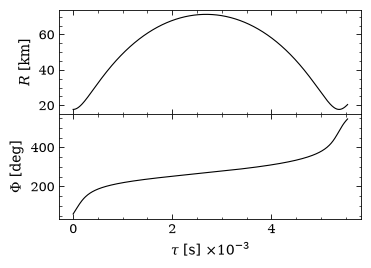

In [7]:
fig, axes = solution.plot_evol(time="tau", coords="bl", Theta=False)

## 5. Several orbits with `rp.plot_sols`

`rp.plot_sols` draws several solutions about the same black hole in one frame:

- the black hole and the spin note appear once;
- each trajectory gets its own colour and legend entry;
- `labels` names the trajectories (by default `"Trajectory 1"`, `"Trajectory 2"`, ...).

It accepts the same `projection`, `interactive` and `style` arguments as
`Solution.plot`. Here three orbits share the semi-major axis and orientation of
Section 1 and differ only in eccentricity.

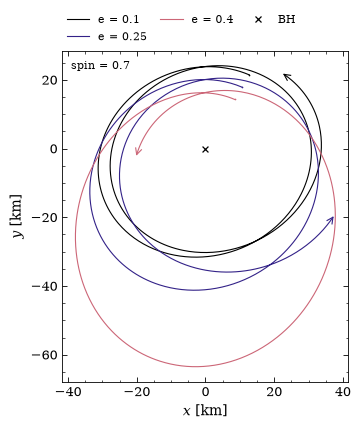

In [8]:
eccentricities = (0.1, 0.25, 0.4)
family = [
    bh.orbit(a=a, e=e, inc=0.5 * u.rad, Omega=0.3 * u.rad, omega=0.8 * u.rad)
    .solve(tau_eval=taus)
    for e in eccentricities
]

fig, ax = rp.plot_sols(*family, projection="xy", labels=[f"e = {e}" for e in eccentricities])

## 6. The `relatipy.plotting` module

All public names live in `relatipy.plotting`:

In [9]:
print(rp.plotting.__all__)

['DEFAULT_STYLE', 'MM', 'TARGETS', 'Corner', 'Frame', 'Interactive', 'Observables', 'Static3D', 'Style', 'Target', 'Views', 'figure_width', 'format_axes', 'new_figure', 'plot_constants', 'plot_corner', 'plot_evolution', 'plot_observables', 'plot_sols', 'plot_solution', 'plot_solution_interactive', 'plot_views', 'preview_orbit', 'preview_orbit_interactive', 'publication_style', 'rc_params', 'save_figure', 'set_axis_label']


In brief:

| Object | Purpose |
| --- | --- |
| `plot_solution`, `preview_orbit` | Functions behind `Solution.plot` and `Orbit.preview`. |
| `plot_sols` | Several solutions about the same black hole in one frame; also available as `rp.plot_sols`. |
| `plot_views` | Three orthogonal Cartesian projections at a shared physical scale. |
| `plot_evolution` | Function behind `Solution.plot_evol`: stored coordinates or osculating elements against `t` or `tau`. |
| `plot_constants` | Function behind `Solution.plot_constants`: $E$, $L_z$ and $Q$, or their drift, against time (see [Constants of motion](07-constants-of-motion.ipynb)). |
| `plot_solution_interactive`, `preview_orbit_interactive` | Plotly three-dimensional figures. |
| `plot_observables`, `plot_corner` | Fit figures: astrometry and velocity against a model, and posterior corner plots (see the next tutorial). |
| `Style`, `DEFAULT_STYLE` | Immutable appearance settings; derive variants with `Style.replace`. |
| `Target`, `TARGETS`, `MM` | Document dimensions in millimetres and text sizes in points; `MM` converts millimetres to inches. |
| `new_figure`, `format_axes`, `publication_style`, `save_figure` | Consistently formatted custom Matplotlib figures. |

`new_figure` and `format_axes` give custom Matplotlib figures the same printed size
and publication format as the RelatiPy ones, and `save_figure(fig, path)` writes PDF
and PNG files; we do not save anything in this tutorial.

## Next steps

- [Observables for MCMC](06-mcmc-observables.ipynb): predict astrometry and
  line-of-sight velocity, and plot a fit with `plot_observables` and `plot_corner`.
- [Solutions and states](04-solutions-and-states.ipynb): what a `Solution` stores.
- {doc}`../reference/plotting`: the full plotting API reference.